In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"
print("CUDA_LAUNCH_BLOCKING=1 — synchronous CUDA errors enabled")


CUDA_LAUNCH_BLOCKING=1 — synchronous CUDA errors enabled


# Notebook 04: Model Experiments

**Objective**: Train and evaluate multi-task age-gender CNN models with different hyperparameter configurations.

**Experiments**:
1. **Baseline**: Default hyperparameters (lr=1e-4, full augmentation, loss weights=1.0/1.0)
2. **Age-Focused**: Increased age loss weight (2.0) to prioritize age performance
3. **Conservative Learning**: Reduced learning rate (5e-5) for more stable convergence
4. **Minimal Augmentation**: Only horizontal flip to test overfitting

**Implementation Checklist Mapping**:
- ✅ Phase 3: Model Architecture
- ✅ Phase 4: Training Loop
- ✅ Phase 5: Hyperparameter Tuning

## Setup

In [1]:
# Install dependencies
%pip install -q torch torchvision numpy pandas scikit-learn albumentations opencv-python matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

# Add src to path
def find_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / 'src').exists():
            return current
        current = current.parent
    return Path.cwd()

project_root = find_project_root()
sys.path.insert(0, str(project_root / 'src'))

# Import project modules
from data.load_utkface import UTKFaceDataset
from data.preprocessing import (
    get_train_transforms,
    get_inference_transforms,
    get_minimal_augmentation_transforms
)
from models.multitask_model import AgeGenderModel
from models.losses import MultiTaskLoss
from training.train import train_one_epoch
from training.validate import validate
from training.evaluate import evaluate_model
from utils.config import ExperimentConfig, save_experiment_results
from utils.visualization import plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: c:\Users\Mark\Projects\age-gender-cnn
PyTorch version: 2.5.1+cu121
CUDA available: True


In [3]:
# Constants
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set random seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Random seed: {SEED}")

Using device: cuda
Random seed: 42


## Data Preparation

In [4]:
# Load metadata (generated by notebook 01)
PROCESSED_ROOT = project_root / 'dataset' / 'processed'
image_dir = project_root / 'dataset' / 'raw' / 'UTKFace'

# Look for any metadata file with timestamp pattern
metadata_candidates = sorted(PROCESSED_ROOT.glob("utkface_metadata_*.csv"))
if not metadata_candidates:
    raise FileNotFoundError(
        f"No metadata CSV found in {PROCESSED_ROOT}.\n"
        "Please run notebook 01_dataset_exploration.ipynb first to generate metadata."
    )

# Use the most recent metadata file
metadata_path = metadata_candidates[-1]
print(f"Using metadata: {metadata_path.name}")

metadata = pd.read_csv(metadata_path)
print(f"Loaded {len(metadata)} samples from metadata")
print(f"\nMetadata columns: {metadata.columns.tolist()}")
print(f"\nFirst few rows:")
display(metadata.head())

Using metadata: utkface_metadata_20260222T151110Z.csv
Loaded 47812 samples from metadata

Metadata columns: ['path', 'relative_path', 'folder', 'filename', 'age', 'gender', 'ethnicity', 'adience_bin', 'size_bytes', 'parse_status', 'parse_reason']

First few rows:


,path,relative_path,folder,filename,age,gender,ethnicity,adience_bin,size_bytes,parse_status,parse_reason
0,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112213500903.jpg,.,100_0_0_20170112213500903.jpg,100.0,0.0,0.0,60+,97833,valid,ok
1,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112213500903....,.,100_0_0_20170112213500903.jpg.chip.jpg,100.0,0.0,0.0,60+,7916,valid,ok
2,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112215240346.jpg,.,100_0_0_20170112215240346.jpg,100.0,0.0,0.0,60+,108750,valid,ok
3,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112215240346....,.,100_0_0_20170112215240346.jpg.chip.jpg,100.0,0.0,0.0,60+,7208,valid,ok
4,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_1_0_20170110183726390.jpg,.,100_1_0_20170110183726390.jpg,100.0,1.0,0.0,60+,60132,valid,ok


In [5]:
# Create stratified splits (70/15/15)
# Stratify by gender and broad age bands to ensure balanced distribution

def create_age_bands(ages):
    """Create broad age bands for stratification."""
    bands = []
    for age in ages:
        if age <= 20:
            bands.append('0-20')
        elif age <= 40:
            bands.append('21-40')
        elif age <= 60:
            bands.append('41-60')
        else:
            bands.append('61+')
    return bands

# Create stratification variable (gender + age band)
metadata['age_band'] = create_age_bands(metadata['age'].values)
metadata['stratify_key'] = metadata['gender'].astype(str) + '_' + metadata['age_band']

# Split: 70% train, 15% val, 15% test
train_idx, temp_idx = train_test_split(
    np.arange(len(metadata)),
    test_size=0.30,
    stratify=metadata['stratify_key'],
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=metadata.iloc[temp_idx]['stratify_key'],
    random_state=SEED
)

print(f"Split sizes:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(metadata)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(metadata)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(metadata)*100:.1f}%)")

# Save splits for reproducibility
splits_path = project_root / 'dataset' / 'processed' / 'utkface_splits.json'
splits_path.parent.mkdir(parents=True, exist_ok=True)

splits_data = {
    'train': train_idx.tolist(),
    'val': val_idx.tolist(),
    'test': test_idx.tolist(),
    'random_seed': SEED,
    'created_at': datetime.now().isoformat()
}

with open(splits_path, 'w') as f:
    json.dump(splits_data, f, indent=2)

print(f"\nSaved splits to {splits_path}")

Split sizes:
  Train: 33468 (70.0%)
  Val:   7172 (15.0%)
  Test:  7172 (15.0%)

Saved splits to c:\Users\Mark\Projects\age-gender-cnn\dataset\processed\utkface_splits.json


In [6]:
# Verify stratification
print("Train set distribution:")
print(metadata.iloc[train_idx]['stratify_key'].value_counts().sort_index())

print("\nValidation set distribution:")
print(metadata.iloc[val_idx]['stratify_key'].value_counts().sort_index())

print("\nTest set distribution:")
print(metadata.iloc[test_idx]['stratify_key'].value_counts().sort_index())

Train set distribution:
stratify_key
0.0_0-20     3207
0.0_21-40    8111
0.0_41-60    4206
0.0_61+      1956
1.0_0-20     3829
1.0_21-40    8881
1.0_41-60    1842
1.0_61+      1436
Name: count, dtype: int64

Validation set distribution:
stratify_key
0.0_0-20      687
0.0_21-40    1738
0.0_41-60     901
0.0_61+       420
1.0_0-20      820
1.0_21-40    1903
1.0_41-60     395
1.0_61+       308
Name: count, dtype: int64

Test set distribution:
stratify_key
0.0_0-20      687
0.0_21-40    1739
0.0_41-60     901
0.0_61+       419
1.0_0-20      821
1.0_21-40    1903
1.0_41-60     394
1.0_61+       308
Name: count, dtype: int64


## Helper Function: Training Pipeline

In [10]:
def run_experiment(config: ExperimentConfig):
    """
    Run complete training experiment with given configuration.
    
    Returns:
        Tuple of (model, history, best_val_loss)
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {config.experiment_id}")
    print(f"Description: {config.description}")
    print(f"{'='*60}\n")
    
    # Create data transforms based on config
    if config.augmentation == 'full':
        train_transform = get_train_transforms()
        print("Using FULL augmentation")
    elif config.augmentation == 'minimal':
        train_transform = get_minimal_augmentation_transforms()
        print("Using MINIMAL augmentation")
    else:
        train_transform = get_inference_transforms()
        print("Using NO augmentation")
    
    val_transform = get_inference_transforms()
    
    # Create datasets
    train_dataset = UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=train_idx.tolist(),
        transform=train_transform
    )
    
    val_dataset = UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=val_idx.tolist(),
        transform=val_transform
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    
    # Create model
    model = AgeGenderModel(
        pretrained_backbone=config.pretrained_backbone,
        freeze_backbone=config.freeze_backbone,
        dropout_rate=config.dropout_rate
    ).to(DEVICE)
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Create optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    loss_fn = MultiTaskLoss(
        age_weight=config.age_loss_weight,
        gender_weight=config.gender_loss_weight
    )
    
    print(f"\nOptimizer: {config.optimizer}")
    print(f"Learning rate: {config.learning_rate}")
    print(f"Loss weights: age={config.age_loss_weight}, gender={config.gender_loss_weight}")
    
    # Training loop
    history = {
        'train_total': [],
        'train_age': [],
        'train_gender': [],
        'val_total': [],
        'val_age': [],
        'val_gender': []
    }
    
    best_val_loss = float('inf')
    best_epoch = 0
    
    checkpoint_dir = project_root / config.checkpoint_dir
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoint_dir / f"{config.experiment_id}_best.pth"
    
    print(f"\nStarting training for {config.num_epochs} epochs...\n")
    
    for epoch in range(1, config.num_epochs + 1):
        # Train
        train_losses = train_one_epoch(
            model, train_loader, optimizer, loss_fn, DEVICE, epoch
        )
        
        # Validate
        val_losses = validate(model, val_loader, loss_fn, DEVICE)
        
        # Record history
        history['train_total'].append(train_losses['total'])
        history['train_age'].append(train_losses['age'])
        history['train_gender'].append(train_losses['gender'])
        history['val_total'].append(val_losses['total'])
        history['val_age'].append(val_losses['age'])
        history['val_gender'].append(val_losses['gender'])
        
        # Print epoch summary
        print(f"\nEpoch {epoch}/{config.num_epochs}:")
        print(f"  Train - Total: {train_losses['total']:.4f}, Age: {train_losses['age']:.4f}, Gender: {train_losses['gender']:.4f}")
        print(f"  Val   - Total: {val_losses['total']:.4f}, Age: {val_losses['age']:.4f}, Gender: {val_losses['gender']:.4f}")
        
        # Save best model
        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            best_epoch = epoch
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'config': config.to_dict()
            }
            
            torch.save(checkpoint, checkpoint_path)
            print(f"  *** New best model saved (val_loss: {best_val_loss:.4f}) ***")
    
    print(f"\nTraining complete!")
    print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Model checkpoint saved to: {checkpoint_path}")
    
    # Load best model
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, history, best_val_loss

## Experiment 1: Baseline

Default configuration:
- Learning rate: 1e-4
- Batch size: 32
- Epochs: 20
- Loss weights: 1.0 / 1.0
- Augmentation: Full

In [8]:
# Create baseline configuration
baseline_config = ExperimentConfig(
    experiment_id="exp01_baseline",
    description="Baseline model with default hyperparameters",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
# Save config
config_path = project_root / 'experiments' / f"{baseline_config.experiment_id}_config_{run_id}.json"
baseline_config.to_json(str(config_path))

# Run experiment
baseline_model, baseline_history, baseline_best_loss = run_experiment(baseline_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp01_baseline_config_20260302T041332Z.json

Experiment: exp01_baseline
Description: Baseline model with default hyperparameters

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:43<00:00,  5.23it/s, val_loss=8.8312, age=8.2225, gender=0.6087] 



Epoch 1/20:
  Train - Total: 9.6170, Age: 9.2456, Gender: 0.3714
  Val   - Total: 6.6494, Age: 6.3632, Gender: 0.2861
  *** New best model saved (val_loss: 6.6494) ***


Validation: 100%|██████████| 225/225 [00:25<00:00,  8.75it/s, val_loss=12.5476, age=12.1655, gender=0.3822]



Epoch 2/20:
  Train - Total: 7.1803, Age: 6.8886, Gender: 0.2917
  Val   - Total: 6.5892, Age: 6.3237, Gender: 0.2656
  *** New best model saved (val_loss: 6.5892) ***


...

Validation: 100%|██████████| 225/225 [00:19<00:00, 11.32it/s, val_loss=8.6725, age=7.6876, gender=0.9849]



Epoch 19/20:
  Train - Total: 4.4572, Age: 4.2898, Gender: 0.1674
  Val   - Total: 5.2888, Age: 5.0796, Gender: 0.2092


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.21it/s, val_loss=8.4081, age=7.7278, gender=0.6803]


Epoch 20/20:
  Train - Total: 4.4177, Age: 4.2513, Gender: 0.1664
  Val   - Total: 5.1960, Age: 4.9924, Gender: 0.2036

Training complete!
Best validation loss: 5.1558 at epoch 18
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp01_baseline_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_9280\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp01_baseline_history_20260302T041332Z.png


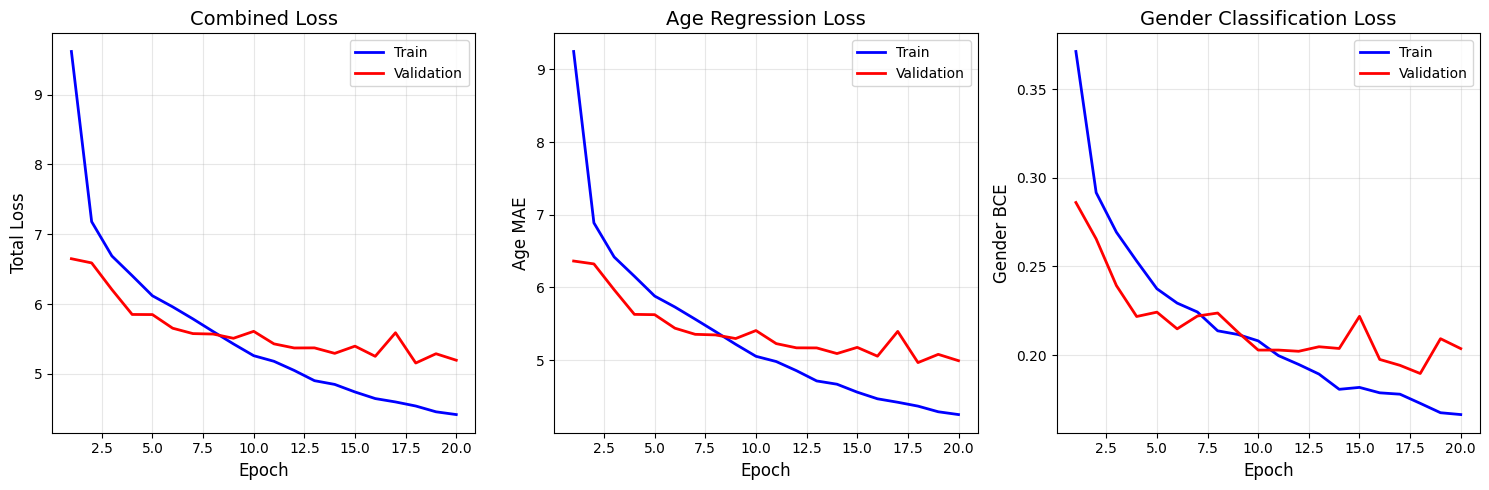

In [9]:
# Plot training history
plot_training_history(
    baseline_history,
    save_path=str(project_root / 'experiments' / f"{baseline_config.experiment_id}_history_{run_id}.png")
)

In [10]:
# Evaluate on validation set
val_dataset = UTKFaceDataset(
    metadata_path=str(metadata_path),
    image_dir=str(image_dir),
    split_indices=val_idx.tolist(),
    transform=get_inference_transforms()
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    baseline_model, val_loader, DEVICE
)

# Save results
save_experiment_results(
    baseline_config,
    metrics,
    baseline_history,
    str(project_root / 'experiments' / f"{baseline_config.experiment_id}_results_{run_id}.json")
)

Evaluating: 100%|██████████| 225/225 [00:33<00:00,  6.68it/s]


Evaluation Results:
  Age MAE: 4.95 years
  Gender Accuracy: 0.9267 (92.67%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp01_baseline_results_20260302T041332Z.json


## Experiment 2: Age-Focused (Increased Age Loss Weight)

Test if prioritizing age loss improves age prediction performance:
- Age loss weight: 2.0
- Gender loss weight: 1.0
- Other settings: Same as baseline

In [11]:
age_focused_config = ExperimentConfig(
    experiment_id="exp02_age_focused",
    description="Increased age loss weight to prioritize age performance",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=2.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

age_focused_config.to_json(str(project_root / 'experiments' / f"{age_focused_config.experiment_id}_config_{run_id}.json"))
age_focused_model, age_focused_history, age_focused_best_loss = run_experiment(age_focused_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp02_age_focused_config_20260302T041332Z.json

Experiment: exp02_age_focused
Description: Increased age loss weight to prioritize age performance

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=2.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:20<00:00, 11.18it/s, val_loss=12.5064, age=6.0813, gender=0.3437]



Epoch 1/20:
  Train - Total: 19.3549, Age: 9.4697, Gender: 0.4155
  Val   - Total: 13.3664, Age: 6.5250, Gender: 0.3164
  *** New best model saved (val_loss: 13.3664) ***


Validation: 100%|██████████| 225/225 [00:21<00:00, 10.63it/s, val_loss=11.0037, age=5.4169, gender=0.1698]



Epoch 2/20:
  Train - Total: 14.2359, Age: 6.9548, Gender: 0.3263
  Val   - Total: 12.2502, Age: 5.9772, Gender: 0.2957
  *** New best model saved (val_loss: 12.2502) ***


...


Epoch 18/20:
  Train - Total: 9.0939, Age: 4.4418, Gender: 0.2104
  Val   - Total: 10.6751, Age: 5.2293, Gender: 0.2166


Validation: 100%|██████████| 225/225 [00:24<00:00,  9.01it/s, val_loss=26.0365, age=12.6229, gender=0.7908]



Epoch 19/20:
  Train - Total: 9.0829, Age: 4.4351, Gender: 0.2126
  Val   - Total: 10.4103, Age: 5.0946, Gender: 0.2210


Validation: 100%|██████████| 225/225 [00:37<00:00,  5.98it/s, val_loss=21.6226, age=10.5754, gender=0.4719]
C:\Users\Mark\AppData\Local\Temp\ipykernel_9280\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any


Epoch 20/20:
  Train - Total: 8.9695, Age: 4.3807, Gender: 0.2082
  Val   - Total: 10.2798, Age: 5.0339, Gender: 0.2121
  *** New best model saved (val_loss: 10.2798) ***

Training complete!
Best validation loss: 10.2798 at epoch 20
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp02_age_focused_best.pth


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp02_age_focused_history_20260302T041332Z.png


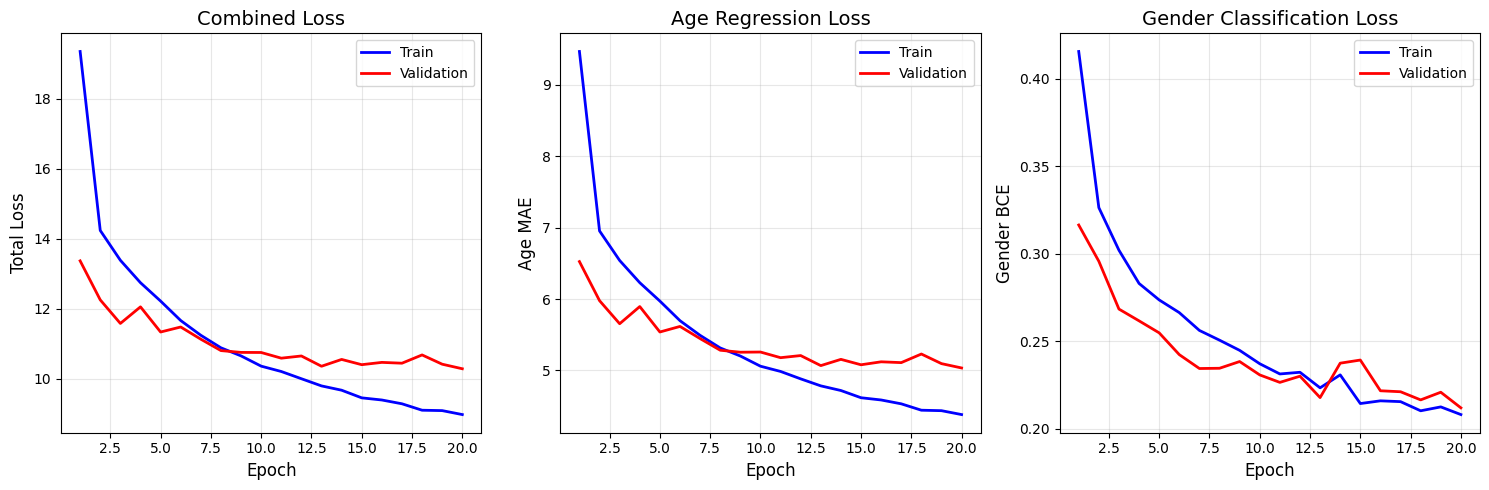

Evaluating: 100%|██████████| 225/225 [00:37<00:00,  6.07it/s]


Evaluation Results:
  Age MAE: 5.01 years
  Gender Accuracy: 0.9137 (91.37%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp02_age_focused_results_20260302T041332Z.json


In [12]:
plot_training_history(
    age_focused_history,
    save_path=str(project_root / 'experiments' / f"{age_focused_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    age_focused_model, val_loader, DEVICE
)

save_experiment_results(
    age_focused_config,
    metrics,
    age_focused_history,
    str(project_root / 'experiments' / f"{age_focused_config.experiment_id}_results_{run_id}.json")
)

## Experiment 3: Conservative Learning (Reduced Learning Rate)

Test if slower learning provides better convergence:
- Learning rate: 5e-5
- Other settings: Same as baseline

In [13]:
conservative_config = ExperimentConfig(
    experiment_id="exp03_conservative_lr",
    description="Reduced learning rate for more stable convergence",
    learning_rate=5e-5,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

conservative_config.to_json(str(project_root / 'experiments' / f"{conservative_config.experiment_id}_config_{run_id}.json"))
conservative_model, conservative_history, conservative_best_loss = run_experiment(conservative_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp03_conservative_lr_config_20260302T041332Z.json

Experiment: exp03_conservative_lr
Description: Reduced learning rate for more stable convergence

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 5e-05
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:20<00:00, 11.19it/s, val_loss=4.2123, age=3.8668, gender=0.3456]



Epoch 1/20:
  Train - Total: 10.7414, Age: 10.3532, Gender: 0.3883
  Val   - Total: 7.1703, Age: 6.8757, Gender: 0.2947
  *** New best model saved (val_loss: 7.1703) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.17it/s, val_loss=5.6386, age=5.4026, gender=0.2360] 



Epoch 2/20:
  Train - Total: 7.3387, Age: 7.0353, Gender: 0.3034
  Val   - Total: 6.3239, Age: 6.0580, Gender: 0.2659
  *** New best model saved (val_loss: 6.3239) ***


...

Validation: 100%|██████████| 225/225 [00:19<00:00, 11.42it/s, val_loss=11.2326, age=11.0055, gender=0.2270]



Epoch 19/20:
  Train - Total: 4.5994, Age: 4.4213, Gender: 0.1781
  Val   - Total: 5.3189, Age: 5.1136, Gender: 0.2053


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.27it/s, val_loss=9.5167, age=9.2125, gender=0.3043]


Epoch 20/20:
  Train - Total: 4.4445, Age: 4.2745, Gender: 0.1700
  Val   - Total: 5.4171, Age: 5.2173, Gender: 0.1999

Training complete!
Best validation loss: 5.3097 at epoch 16
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp03_conservative_lr_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_9280\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp03_conservative_lr_history_20260302T041332Z.png


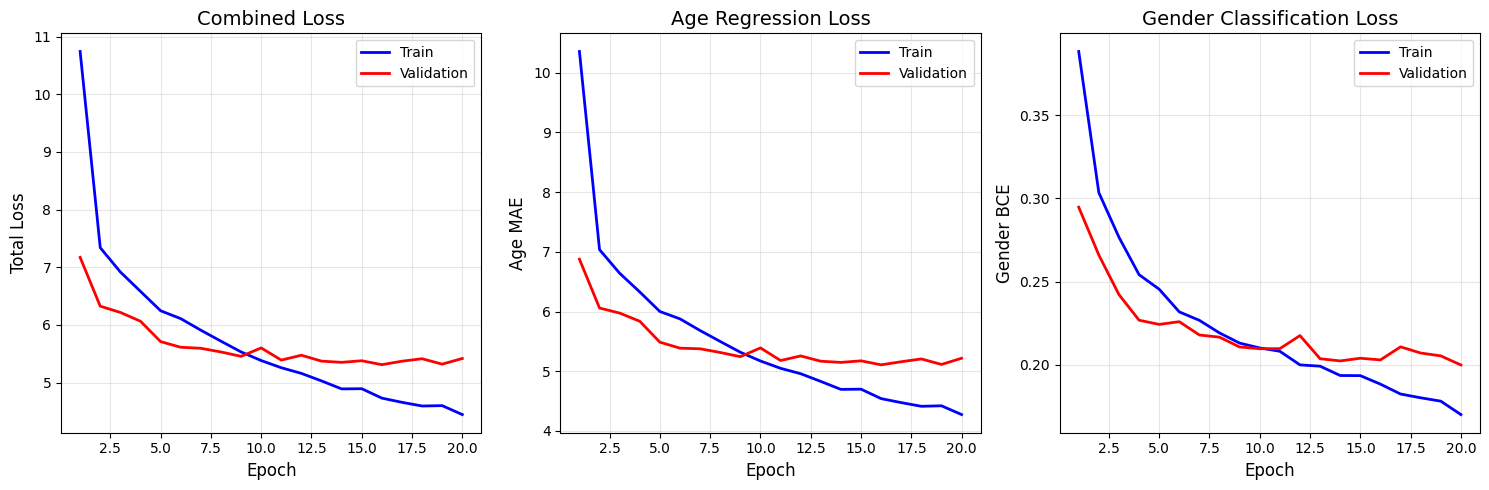

Evaluating: 100%|██████████| 225/225 [00:30<00:00,  7.38it/s]


Evaluation Results:
  Age MAE: 5.10 years
  Gender Accuracy: 0.9179 (91.79%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp03_conservative_lr_results_20260302T041332Z.json


In [14]:
plot_training_history(
    conservative_history,
    save_path=str(project_root / 'experiments' / f"{conservative_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    conservative_model, val_loader, DEVICE
)

save_experiment_results(
    conservative_config,
    metrics,
    conservative_history,
    str(project_root / 'experiments' / f"{conservative_config.experiment_id}_results_{run_id}.json")
)

## Experiment 4: Minimal Augmentation

Test overfitting with reduced augmentation:
- Augmentation: Minimal (only horizontal flip)
- Other settings: Same as baseline

In [15]:
minimal_aug_config = ExperimentConfig(
    experiment_id="exp04_minimal_aug",
    description="Minimal augmentation to test overfitting",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="minimal",
    random_seed=SEED,
    device=str(DEVICE)
)

minimal_aug_config.to_json(str(project_root / 'experiments' / f"{minimal_aug_config.experiment_id}_config_{run_id}.json"))
minimal_aug_model, minimal_aug_history, minimal_aug_best_loss = run_experiment(minimal_aug_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp04_minimal_aug_config_20260302T041332Z.json

Experiment: exp04_minimal_aug
Description: Minimal augmentation to test overfitting

Using MINIMAL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:24<00:00,  9.01it/s, val_loss=5.6195, age=5.2587, gender=0.3608] 



Epoch 1/20:
  Train - Total: 9.4071, Age: 9.0435, Gender: 0.3636
  Val   - Total: 6.7728, Age: 6.4818, Gender: 0.2911
  *** New best model saved (val_loss: 6.7728) ***


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.51it/s, val_loss=6.2873, age=5.8654, gender=0.4219]



Epoch 2/20:
  Train - Total: 6.9852, Age: 6.7076, Gender: 0.2776
  Val   - Total: 6.2882, Age: 6.0396, Gender: 0.2486
  *** New best model saved (val_loss: 6.2882) ***


...

Validation: 100%|██████████| 225/225 [00:19<00:00, 11.37it/s, val_loss=5.4211, age=4.8416, gender=0.5795]



Epoch 19/20:
  Train - Total: 3.9398, Age: 3.7933, Gender: 0.1465
  Val   - Total: 5.2255, Age: 5.0171, Gender: 0.2084


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.01it/s, val_loss=7.1098, age=6.2674, gender=0.8424]


Epoch 20/20:
  Train - Total: 3.8541, Age: 3.7138, Gender: 0.1403
  Val   - Total: 5.3705, Age: 5.1601, Gender: 0.2103

Training complete!
Best validation loss: 5.2222 at epoch 17
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp04_minimal_aug_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_9280\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp04_minimal_aug_history_20260302T041332Z.png


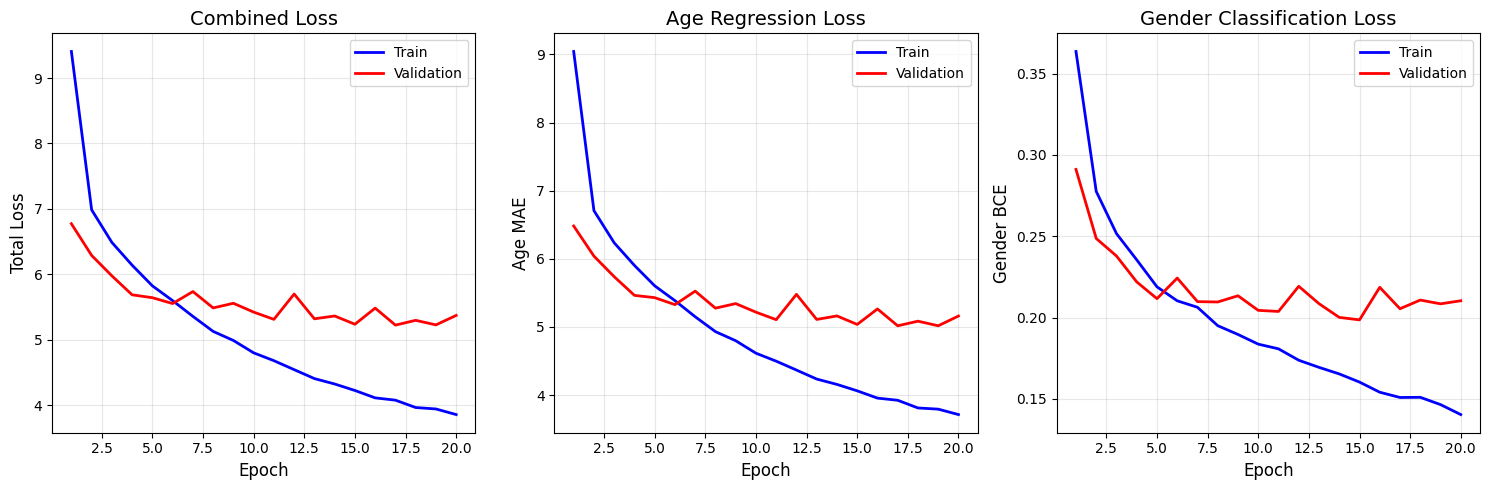

Evaluating: 100%|██████████| 225/225 [00:31<00:00,  7.22it/s]


Evaluation Results:
  Age MAE: 5.02 years
  Gender Accuracy: 0.9237 (92.37%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp04_minimal_aug_results_20260302T041332Z.json


In [16]:
plot_training_history(
    minimal_aug_history,
    save_path=str(project_root / 'experiments' / f"{minimal_aug_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    minimal_aug_model, val_loader, DEVICE
)

save_experiment_results(
    minimal_aug_config,
    metrics,
    minimal_aug_history,
    str(project_root / 'experiments' / f"{minimal_aug_config.experiment_id}_results_{run_id}.json")
)

## Experiment Summary & Comparison

In [17]:
# Load all experiment results
from utils.config import load_experiment_results

experiments = [
    'exp01_baseline',
    'exp02_age_focused',
    'exp03_conservative_lr',
    'exp04_minimal_aug'
]

results_summary = []

for exp_id in experiments:
    results_path = project_root / 'experiments' / f"{exp_id}_results_{run_id}.json"
    if results_path.exists():
        results = load_experiment_results(str(results_path))
        results_summary.append({
            'Experiment': exp_id,
            'Description': results['config'].description,
            'Age MAE': results['metrics']['age_mae'],
            'Gender Acc': results['metrics']['gender_accuracy'],
            'LR': results['config'].learning_rate,
            'Age Weight': results['config'].age_loss_weight,
            'Augmentation': results['config'].augmentation
        })

summary_df = pd.DataFrame(results_summary)
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
display(summary_df)

# Identify best model
best_age_idx = summary_df['Age MAE'].idxmin()
best_gender_idx = summary_df['Gender Acc'].idxmax()

print(f"\nBest Age Performance: {summary_df.loc[best_age_idx, 'Experiment']}")
print(f"  Age MAE: {summary_df.loc[best_age_idx, 'Age MAE']:.2f} years")

print(f"\nBest Gender Performance: {summary_df.loc[best_gender_idx, 'Experiment']}")
print(f"  Gender Accuracy: {summary_df.loc[best_gender_idx, 'Gender Acc']:.4f}")


EXPERIMENT SUMMARY


,Experiment,Description,Age MAE,Gender Acc,LR,Age Weight,Augmentation
0,exp01_baseline,Baseline model with default hyperparameters,4.954776,0.926659,0.00010,1.0,full
1,exp02_age_focused,Increased age loss weight to prioritize age pe...,5.012254,0.913692,0.00010,2.0,full
2,exp03_conservative_lr,Reduced learning rate for more stable convergence,5.100276,0.917875,0.00005,1.0,full
3,exp04_minimal_aug,Minimal augmentation to test overfitting,5.016036,0.923731,0.00010,1.0,minimal



Best Age Performance: exp01_baseline
  Age MAE: 4.95 years

Best Gender Performance: exp01_baseline
  Gender Accuracy: 0.9267


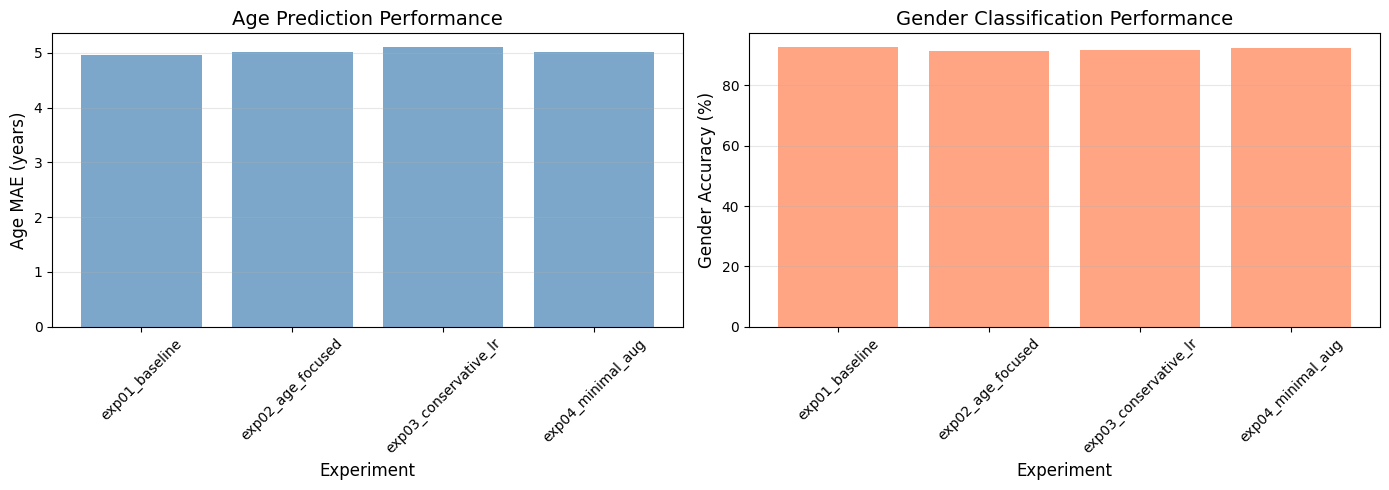

In [18]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age MAE comparison
axes[0].bar(summary_df['Experiment'], summary_df['Age MAE'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Experiment', fontsize=12)
axes[0].set_ylabel('Age MAE (years)', fontsize=12)
axes[0].set_title('Age Prediction Performance', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Gender accuracy comparison
axes[1].bar(summary_df['Experiment'], summary_df['Gender Acc'] * 100, color='coral', alpha=0.7)
axes[1].set_xlabel('Experiment', fontsize=12)
axes[1].set_ylabel('Gender Accuracy (%)', fontsize=12)
axes[1].set_title('Gender Classification Performance', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(project_root / 'experiments' / 'experiments_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Advanced Experiments: Extended Analysis

Building on the baseline experiments, we'll test regularization, training dynamics, and fairness improvements.

In [11]:
import torch
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler


# ============================================================================
# Label Smoothing Loss for Gender Classification
# ============================================================================
class LabelSmoothingLoss(torch.nn.Module):
    """BCE loss with label smoothing for binary gender classification.

    Compatible with models that output a single probability via Sigmoid.
    Applies smoothing by replacing hard {0, 1} targets with
    {smoothing/2, 1 - smoothing/2}.
    """
    
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        
    def forward(self, probs, targets):
        """
        Args:
            probs:   (batch_size,) gender probabilities from Sigmoid
            targets: (batch_size,) binary float targets {0.0, 1.0}
        """
        targets = targets.float()
        # Smooth hard labels: 0 → smoothing/2,  1 → 1 - smoothing/2
        smooth_targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy(probs.squeeze(), smooth_targets)


# ============================================================================
# Learning Rate Scheduler with Warmup
# ============================================================================
class WarmupCosineScheduler:
    """Cosine annealing with linear warmup."""
    
    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.current_epoch = 0
        
    def step(self):
        self.current_epoch += 1
        
        if self.current_epoch <= self.warmup_epochs:
            # Linear warmup
            lr = self.base_lr * (self.current_epoch / self.warmup_epochs)
        else:
            # Cosine annealing after warmup
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.base_lr * (1 + torch.cos(torch.tensor(3.14159 * progress))) / 2
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr


# ============================================================================
# Balanced Sampling by Demographics
# ============================================================================
def create_demographic_sampler(metadata, split_indices, batch_size):
    """
    Create a sampler that ensures balanced age/gender distribution per batch.
    """
    split_metadata = metadata.iloc[split_indices].reset_index(drop=True)
    
    # Create demographic groups
    split_metadata['demo_group'] = (
        split_metadata['gender'].astype(str) + '_' + 
        split_metadata['age'].apply(
            lambda x: '0-20' if x <= 20 else ('21-40' if x <= 40 else ('41-60' if x <= 60 else '61+'))
        )
    )
    
    # Compute inverse frequencies for each demographic group
    group_counts = split_metadata['demo_group'].value_counts()
    weights = 1.0 / split_metadata['demo_group'].map(group_counts)
    weights = weights / weights.sum()
    
    sampler = WeightedRandomSampler(
        weights=weights.values,
        num_samples=len(split_indices),
        replacement=True
    )
    
    return sampler


print("✓ Advanced loss functions and sampling strategies loaded")


✓ Advanced loss functions and sampling strategies loaded


In [12]:
# ============================================================================
def run_advanced_experiment(config: ExperimentConfig, use_label_smoothing=False, 
                            use_lr_scheduler=False, use_balanced_sampler=False,
                            early_stopping_patience=None):
    """
    Run training with advanced regularization and scheduling options.
    
    Args:
        config: ExperimentConfig object
        use_label_smoothing: Apply label smoothing to gender loss
        use_lr_scheduler: Use cosine annealing with warmup
        use_balanced_sampler: Balance demographics in each batch
        early_stopping_patience: Epochs without improvement before stopping
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {config.experiment_id}")
    print(f"Description: {config.description}")
    if use_label_smoothing:
        print("✓ Label Smoothing: ON")
    if use_lr_scheduler:
        print("✓ LR Schedule: Cosine annealing with warmup")
    if use_balanced_sampler:
        print("✓ Balanced Sampling: ON")
    if early_stopping_patience:
        print(f"✓ Early Stopping: patience={early_stopping_patience}")
    print(f"{'='*60}\n")
    
    # Create data transforms
    if config.augmentation == 'full':
        train_transform = get_train_transforms()
    elif config.augmentation == 'minimal':
        train_transform = get_minimal_augmentation_transforms()
    else:
        train_transform = get_inference_transforms()
    
    val_transform = get_inference_transforms()
    
    # Create datasets
    train_dataset = UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=train_idx.tolist(),
        transform=train_transform
    )
    
    val_dataset = UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=val_idx.tolist(),
        transform=val_transform
    )
    
    # Create data loaders with optional balanced sampling
    if use_balanced_sampler:
        sampler = create_demographic_sampler(metadata, train_idx, config.batch_size)
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            sampler=sampler,
            num_workers=2,
            pin_memory=True
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    
    # Create model
    model = AgeGenderModel(
        pretrained_backbone=config.pretrained_backbone,
        freeze_backbone=config.freeze_backbone,
        dropout_rate=config.dropout_rate
    ).to(DEVICE)
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Create optimizer
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    
    # Create loss function
    loss_fn = MultiTaskLoss(
        age_weight=config.age_loss_weight,
        gender_weight=config.gender_loss_weight
    )
    
    # Optional: label smoothing wrapper for gender loss
    smoother = LabelSmoothingLoss(smoothing=0.1) if use_label_smoothing else None
    
    # Optional: learning rate scheduler
    if use_lr_scheduler:
        lr_scheduler = WarmupCosineScheduler(
            optimizer, 
            warmup_epochs=2,
            total_epochs=config.num_epochs,
            base_lr=config.learning_rate
        )
    
    print(f"\nLearning rate: {config.learning_rate}")
    print(f"Loss weights: age={config.age_loss_weight}, gender={config.gender_loss_weight}")
    
    # Training loop
    history = {
        'train_total': [], 'train_age': [], 'train_gender': [],
        'val_total': [], 'val_age': [], 'val_gender': []
    }
    
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0
    
    checkpoint_dir = project_root / config.checkpoint_dir
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoint_dir / f"{config.experiment_id}_best.pth"
    
    print(f"\nStarting training for {config.num_epochs} epochs...\n")
    
    for epoch in range(1, config.num_epochs + 1):
        # Training step
        model.train()
        train_age_loss, train_gender_loss, train_total_loss = 0, 0, 0
        num_batches = 0
        
        for batch_idx, (images, ages, genders) in enumerate(train_loader):
            images = images.to(DEVICE)
            ages = ages.to(DEVICE)
            genders = genders.to(DEVICE)
            
            optimizer.zero_grad()
            
            age_pred, gender_pred = model(images)
            
            # Age loss
            age_loss = F.smooth_l1_loss(age_pred.squeeze(), ages.float())
            
            # Gender loss: model outputs (batch, 1) via Sigmoid → use BCE, not CrossEntropy
            if smoother is not None:
                gender_loss = smoother(gender_pred.squeeze(), genders.float())
            else:
                gender_loss = F.binary_cross_entropy(gender_pred.squeeze(), genders.float())
            
            # Combined loss
            total_loss = (config.age_loss_weight * age_loss + 
                         config.gender_loss_weight * gender_loss)
            
            total_loss.backward()
            optimizer.step()
            
            train_age_loss += age_loss.item()
            train_gender_loss += gender_loss.item()
            train_total_loss += total_loss.item()
            num_batches += 1
        
        # LR Scheduler step
        if use_lr_scheduler:
            lr_scheduler.step()
        
        # Average losses
        train_losses = {
            'total': train_total_loss / num_batches,
            'age': train_age_loss / num_batches,
            'gender': train_gender_loss / num_batches
        }
        
        # Validation
        val_losses = validate(model, val_loader, loss_fn, DEVICE)
        
        # Record history
        history['train_total'].append(train_losses['total'])
        history['train_age'].append(train_losses['age'])
        history['train_gender'].append(train_losses['gender'])
        history['val_total'].append(val_losses['total'])
        history['val_age'].append(val_losses['age'])
        history['val_gender'].append(val_losses['gender'])
        
        # Print epoch summary
        print(f"Epoch {epoch}/{config.num_epochs}:")
        print(f"  Train - Total: {train_losses['total']:.4f}, Age: {train_losses['age']:.4f}, Gender: {train_losses['gender']:.4f}")
        print(f"  Val   - Total: {val_losses['total']:.4f}, Age: {val_losses['age']:.4f}, Gender: {val_losses['gender']:.4f}")
        
        # Early stopping check
        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            best_epoch = epoch
            patience_counter = 0
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'config': config.to_dict()
            }
            
            torch.save(checkpoint, checkpoint_path)
            print(f"  *** New best model saved (val_loss: {best_val_loss:.4f}) ***")
        else:
            if early_stopping_patience:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"\nEarly stopping at epoch {epoch} (patience={early_stopping_patience})")
                    break
    
    print(f"\nTraining complete!")
    print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Model checkpoint saved to: {checkpoint_path}")
    
    # Load best model
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, history, best_val_loss


## Experiment 5: Dropout Tuning (Higher Dropout)

Test increased dropout for better regularization:
- Dropout rate: 0.5 (vs 0.2 default)
- Learning rate: 1e-4
- Full augmentation


Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp05_high_dropout_config_20260302T041332Z.json

Experiment: exp05_high_dropout
Description: Higher dropout rate (0.5) for regularization

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:43<00:00,  5.17it/s, val_loss=8.9310, age=8.5907, gender=0.3404]



Epoch 1/20:
  Train - Total: 10.5492, Age: 10.1584, Gender: 0.3908
  Val   - Total: 6.9867, Age: 6.6896, Gender: 0.2971
  *** New best model saved (val_loss: 6.9867) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.18it/s, val_loss=8.6429, age=8.1743, gender=0.4686]



Epoch 2/20:
  Train - Total: 7.9446, Age: 7.6457, Gender: 0.2989
  Val   - Total: 6.7358, Age: 6.4771, Gender: 0.2587
  *** New best model saved (val_loss: 6.7358) ***


...


Epoch 18/20:
  Train - Total: 5.8246, Age: 5.6485, Gender: 0.1761
  Val   - Total: 5.5659, Age: 5.3612, Gender: 0.2047


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.25it/s, val_loss=10.7947, age=9.8533, gender=0.9414]



Epoch 19/20:
  Train - Total: 5.7503, Age: 5.5748, Gender: 0.1755
  Val   - Total: 5.3887, Age: 5.1880, Gender: 0.2006


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.19it/s, val_loss=10.5133, age=9.7536, gender=0.7597]
C:\Users\Mark\AppData\Local\Temp\ipykernel_9280\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any 


Epoch 20/20:
  Train - Total: 5.7197, Age: 5.5498, Gender: 0.1699
  Val   - Total: 5.4085, Age: 5.1953, Gender: 0.2132

Training complete!
Best validation loss: 5.3276 at epoch 17
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp05_high_dropout_best.pth
Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp05_high_dropout_history_20260302T041332Z.png


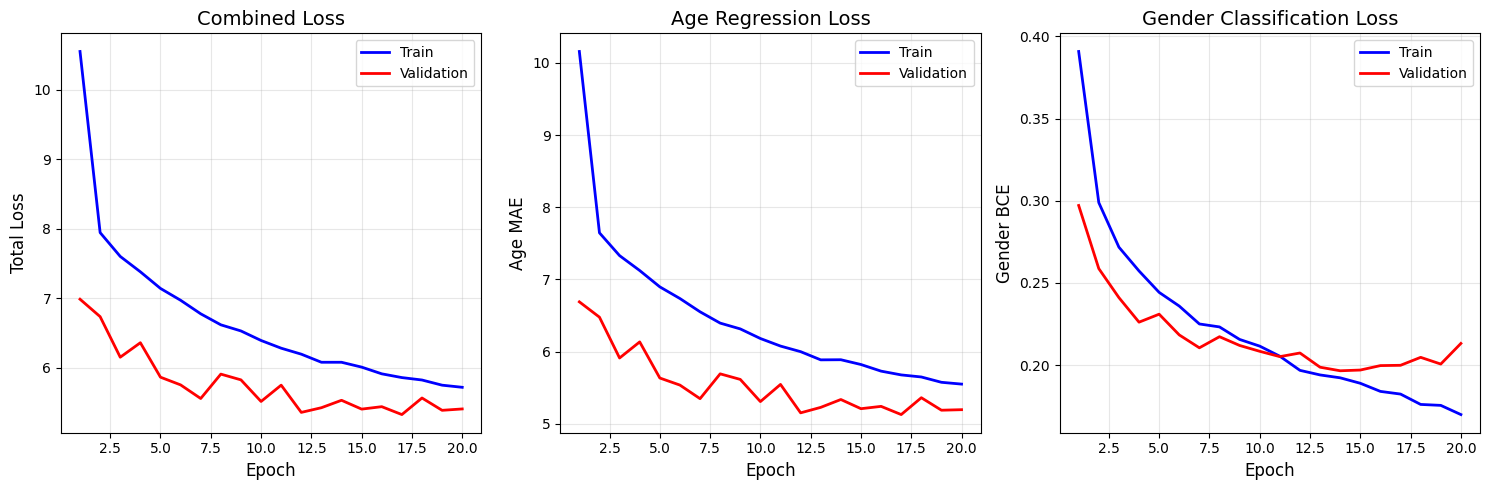

Evaluating: 100%|██████████| 225/225 [00:31<00:00,  7.07it/s]


Evaluation Results:
  Age MAE: 5.11 years
  Gender Accuracy: 0.9207 (92.07%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp05_high_dropout_results_20260302T041332Z.json


In [22]:
dropout_config = ExperimentConfig(
    experiment_id="exp05_high_dropout",
    description="Higher dropout rate (0.5) for regularization",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    dropout_rate=0.5,
    random_seed=SEED,
    device=str(DEVICE)
)

dropout_config.to_json(str(project_root / 'experiments' / f"{dropout_config.experiment_id}_config_{run_id}.json"))
dropout_model, dropout_history, dropout_best_loss = run_experiment(dropout_config)

plot_training_history(
    dropout_history,
    save_path=str(project_root / 'experiments' / f"{dropout_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    dropout_model, val_loader, DEVICE
)

save_experiment_results(
    dropout_config,
    metrics,
    dropout_history,
    str(project_root / 'experiments' / f"{dropout_config.experiment_id}_results_{run_id}.json")
)

## Experiment 6: Learning Rate Schedule with Warmup

Test adaptive learning rate with warmup and cosine annealing:
- Warmup: 2 epochs, then cosine decay
- Base learning rate: 1e-4
- Full augmentation


In [6]:
# ── Debug Step 1: Create a fresh val_loader & validate labels ─────────────────
import torch
from torch.utils.data import DataLoader
from data.load_utkface import UTKFaceDataset
from data.preprocessing import get_inference_transforms

_val_transform = get_inference_transforms()
_val_dataset = UTKFaceDataset(
    metadata_path=str(metadata_path),
    image_dir=str(image_dir),
    split_indices=val_idx.tolist(),
    transform=_val_transform
)
_debug_loader = DataLoader(_val_dataset, batch_size=32, shuffle=False, num_workers=0)

def validate_dataloader(loader, name="loader"):
    print(f"Validating {name} ({len(loader)} batches)...")
    all_gender_vals = set()
    nan_batches = []

    for batch_idx, (images, ages, genders) in enumerate(loader):
        all_gender_vals.update(genders.unique().tolist())

        if torch.isnan(images).any() or torch.isinf(images).any():
            nan_batches.append(("images", batch_idx))
        if torch.isnan(ages.float()).any():
            nan_batches.append(("ages", batch_idx))
        if torch.isnan(genders.float()).any():
            nan_batches.append(("genders", batch_idx))

        if batch_idx == 0:
            print(f"  Batch 0 shapes  → images: {images.shape}, ages: {ages.shape}, genders: {genders.shape}")
            print(f"  Batch 0 dtypes  → images: {images.dtype}, ages: {ages.dtype}, genders: {genders.dtype}")
            print(f"  Age range       → [{ages.min():.1f}, {ages.max():.1f}]")
            print(f"  Gender unique   → {genders.unique().tolist()}")

    print(f"\n  All gender values seen: {sorted(all_gender_vals)}")
    if nan_batches:
        print(f"  ❌ NaN/Inf found in: {nan_batches}")
    else:
        print("  ✅ No NaN/Inf in any batch")

    if any(v < 0 or v > 1 for v in all_gender_vals):
        print(f"  ❌ Gender labels out of range [0,1]: {sorted(all_gender_vals)}")
    else:
        print(f"  ✅ Gender labels in valid range [0,1]")

validate_dataloader(_debug_loader, "val_loader")


Validating val_loader (225 batches)...
  Batch 0 shapes  → images: torch.Size([32, 3, 224, 224]), ages: torch.Size([32]), genders: torch.Size([32])
  Batch 0 dtypes  → images: torch.float32, ages: torch.float64, genders: torch.float64
  Age range       → [1.0, 90.0]
  Gender unique   → [0.0, 1.0]

  All gender values seen: [0.0, 1.0]
  ✅ No NaN/Inf in any batch
  ✅ Gender labels in valid range [0,1]


In [8]:
# ── Debug Step 2: CPU forward pass on a single batch ──────────────────────────
import torch
import torch.nn.functional as F
from models.multitask_model import AgeGenderModel

def test_single_batch_cpu(loader, pretrained=False, freeze=False, dropout=0.3):
    """Run one forward+backward pass entirely on CPU to surface the real error."""
    print("Testing single batch on CPU...")
    model_cpu = AgeGenderModel(
        pretrained_backbone=pretrained,
        freeze_backbone=freeze,
        dropout_rate=dropout
    ).cpu()
    model_cpu.train()

    images, ages, genders = next(iter(loader))
    images  = images.cpu().float()
    ages    = ages.cpu().float()
    genders = genders.cpu().float()   # float for BCE

    print(f"  genders dtype  : {genders.dtype}")
    print(f"  genders unique : {genders.unique().tolist()}")
    print(f"  ages range     : [{ages.min():.1f}, {ages.max():.1f}]")
    print(f"  images min/max : [{images.min():.3f}, {images.max():.3f}]")

    try:
        age_pred, gender_pred = model_cpu(images)
        print(f"  gender_pred shape : {gender_pred.shape}  (num outputs = {gender_pred.shape[1]})")
        age_loss    = F.smooth_l1_loss(age_pred.squeeze(), ages)
        # Model uses Sigmoid → BCE, not CrossEntropy
        gender_loss = F.binary_cross_entropy(gender_pred.squeeze(), genders)
        total_loss  = age_loss + gender_loss
        total_loss.backward()
        print("  ✅ CPU forward+backward succeeded")
        print(f"     age_loss={age_loss.item():.4f}  gender_loss={gender_loss.item():.4f}")
    except RuntimeError as e:
        print(f"  ❌ CPU error: {e}")

test_single_batch_cpu(_debug_loader)


Testing single batch on CPU...
  genders dtype  : torch.float32
  genders unique : [0.0, 1.0]
  ages range     : [1.0, 90.0]
  images min/max : [-2.118, 2.640]
  gender_pred shape : torch.Size([32, 1])  (num outputs = 1)
  ✅ CPU forward+backward succeeded
     age_loss=35.1367  gender_loss=0.7109


In [14]:
from datetime import datetime, timezone
from torch.utils.data import DataLoader
from data.load_utkface import UTKFaceDataset
from data.preprocessing import get_inference_transforms

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
print(f"run_id = {run_id}")

# Create the global val_loader used by evaluate_model after training
val_loader = DataLoader(
    UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=val_idx.tolist(),
        transform=get_inference_transforms()
    ),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print(f"val_loader ready ({len(val_loader)} batches)")


run_id = 20260302T121659Z
val_loader ready (225 batches)


Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp06_lr_schedule_config_20260302T121659Z.json

Experiment: exp06_lr_schedule
Description: Learning rate schedule with warmup and cosine annealing
✓ LR Schedule: Cosine annealing with warmup

Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:57<00:00,  3.91it/s, val_loss=9.5783, age=9.2619, gender=0.3164]


Epoch 1/20:
  Train - Total: 9.1669, Age: 8.7961, Gender: 0.3707
  Val   - Total: 6.5687, Age: 6.2923, Gender: 0.2764
  *** New best model saved (val_loss: 6.5687) ***


Validation: 100%|██████████| 225/225 [00:23<00:00,  9.63it/s, val_loss=7.8096, age=7.2352, gender=0.5743]


Epoch 2/20:
  Train - Total: 6.5683, Age: 6.2873, Gender: 0.2810
  Val   - Total: 5.9591, Age: 5.7119, Gender: 0.2472
  *** New best model saved (val_loss: 5.9591) ***


...

Epoch 18/20:
  Train - Total: 3.5757, Age: 3.4166, Gender: 0.1592
  Val   - Total: 5.1122, Age: 4.9230, Gender: 0.1892
  *** New best model saved (val_loss: 5.1122) ***


Validation: 100%|██████████| 225/225 [00:32<00:00,  6.82it/s, val_loss=11.0662, age=10.4482, gender=0.6180]


Epoch 19/20:
  Train - Total: 3.5792, Age: 3.4204, Gender: 0.1588
  Val   - Total: 5.0862, Age: 4.8979, Gender: 0.1883
  *** New best model saved (val_loss: 5.0862) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 10.77it/s, val_loss=11.1509, age=10.4937, gender=0.6572]
C:\Users\Mark\AppData\Local\Temp\ipykernel_17336\689969969.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any

Epoch 20/20:
  Train - Total: 3.5459, Age: 3.3892, Gender: 0.1567
  Val   - Total: 5.0695, Age: 4.8789, Gender: 0.1907
  *** New best model saved (val_loss: 5.0695) ***

Training complete!
Best validation loss: 5.0695 at epoch 20
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp06_lr_schedule_best.pth
Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp06_lr_schedule_history_20260302T121659Z.png


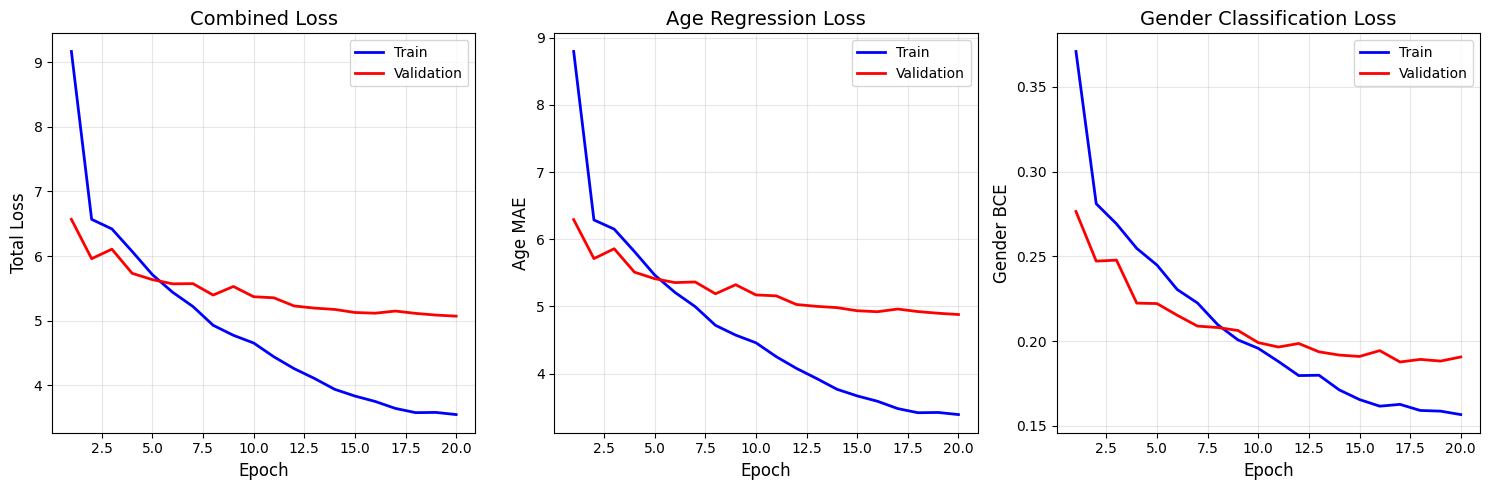

Evaluating: 100%|██████████| 225/225 [00:20<00:00, 10.77it/s]


Evaluation Results:
  Age MAE: 4.86 years
  Gender Accuracy: 0.9296 (92.96%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp06_lr_schedule_results_20260302T121659Z.json


In [15]:
schedule_config = ExperimentConfig(
    experiment_id="exp06_lr_schedule",
    description="Learning rate schedule with warmup and cosine annealing",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

schedule_config.to_json(str(project_root / 'experiments' / f"{schedule_config.experiment_id}_config_{run_id}.json"))
schedule_model, schedule_history, schedule_best_loss = run_advanced_experiment(
    schedule_config,
    use_lr_scheduler=True
)

plot_training_history(
    schedule_history,
    save_path=str(project_root / 'experiments' / f"{schedule_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    schedule_model, val_loader, DEVICE
)

save_experiment_results(
    schedule_config,
    metrics,
    schedule_history,
    str(project_root / 'experiments' / f"{schedule_config.experiment_id}_results_{run_id}.json")
)

## Experiment 7: Extended Training with Early Stopping

Allow more training time with early stopping to prevent overfitting:
- Max epochs: 50
- Early stopping patience: 5 epochs
- Learning rate: 1e-4
- Full augmentation


Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp07_extended_early_stop_config_20260302T121659Z.json

Experiment: exp07_extended_early_stop
Description: Extended training (50 epochs) with early stopping
✓ LR Schedule: Cosine annealing with warmup
✓ Early Stopping: patience=5

Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 50 epochs...



Validation: 100%|██████████| 225/225 [00:41<00:00,  5.39it/s, val_loss=7.0594, age=6.9013, gender=0.1581]


Epoch 1/50:
  Train - Total: 9.0494, Age: 8.6913, Gender: 0.3581
  Val   - Total: 6.6940, Age: 6.3992, Gender: 0.2947
  *** New best model saved (val_loss: 6.6940) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.23it/s, val_loss=6.9486, age=6.8820, gender=0.0666]


Epoch 2/50:
  Train - Total: 6.5294, Age: 6.2538, Gender: 0.2756
  Val   - Total: 6.0313, Age: 5.7832, Gender: 0.2481
  *** New best model saved (val_loss: 6.0313) ***


...

Epoch 17/50:
  Train - Total: 3.9334, Age: 3.7667, Gender: 0.1667
  Val   - Total: 5.2535, Age: 5.0547, Gender: 0.1989


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.19it/s, val_loss=12.1487, age=11.7649, gender=0.3838]


Epoch 18/50:
  Train - Total: 3.8573, Age: 3.6932, Gender: 0.1641
  Val   - Total: 5.4007, Age: 5.1904, Gender: 0.2103


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.34it/s, val_loss=8.8119, age=8.1367, gender=0.6752]
C:\Users\Mark\AppData\Local\Temp\ipykernel_17336\689969969.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

Epoch 19/50:
  Train - Total: 3.7946, Age: 3.6316, Gender: 0.1630
  Val   - Total: 5.3616, Age: 5.1612, Gender: 0.2005

Early stopping at epoch 19 (patience=5)

Training complete!
Best validation loss: 5.2257 at epoch 14
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp07_extended_early_stop_best.pth
Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp07_extended_early_stop_history_20260302T121659Z.png


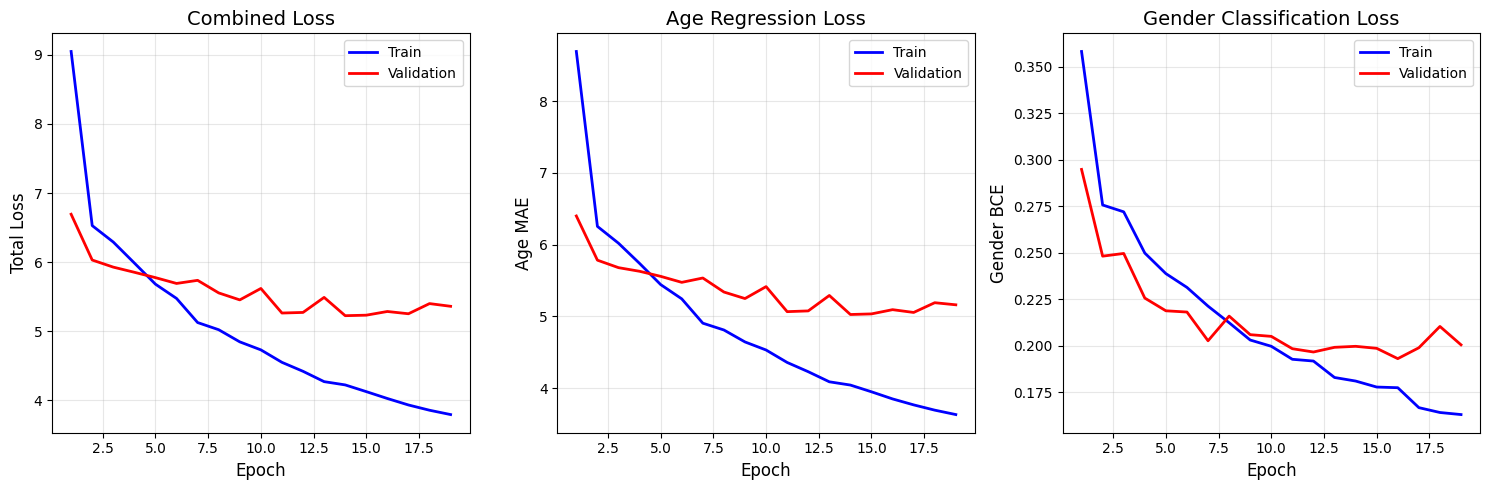

Evaluating: 100%|██████████| 225/225 [00:19<00:00, 11.42it/s]


Evaluation Results:
  Age MAE: 5.00 years
  Gender Accuracy: 0.9205 (92.05%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp07_extended_early_stop_results_20260302T121659Z.json


In [16]:
extended_config = ExperimentConfig(
    experiment_id="exp07_extended_early_stop",
    description="Extended training (50 epochs) with early stopping",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=50,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

extended_config.to_json(str(project_root / 'experiments' / f"{extended_config.experiment_id}_config_{run_id}.json"))
extended_model, extended_history, extended_best_loss = run_advanced_experiment(
    extended_config,
    use_lr_scheduler=True,
    early_stopping_patience=5
)

plot_training_history(
    extended_history,
    save_path=str(project_root / 'experiments' / f"{extended_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    extended_model, val_loader, DEVICE
)

save_experiment_results(
    extended_config,
    metrics,
    extended_history,
    str(project_root / 'experiments' / f"{extended_config.experiment_id}_results_{run_id}.json")
)

## Experiment 8: Balanced Demographic Sampling

Ensure equal representation of age/gender groups per batch for fairness:
- Balanced sampling by (gender, age_band)
- Learning rate: 1e-4
- Full augmentation
- Early stopping with patience=5


Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp08_balanced_sampling_config_20260302T121659Z.json

Experiment: exp08_balanced_sampling
Description: Balanced sampling for demographic fairness
✓ LR Schedule: Cosine annealing with warmup
✓ Balanced Sampling: ON
✓ Early Stopping: patience=5



c:\Users\Mark\Projects\age-gender-cnn\venv312\Lib\site-packages\torch\utils\data\sampler.py:271: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)


Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 50 epochs...



Validation: 100%|██████████| 225/225 [00:19<00:00, 11.51it/s, val_loss=9.0572, age=8.8717, gender=0.1855] 


Epoch 1/50:
  Train - Total: 10.9941, Age: 10.5917, Gender: 0.4024
  Val   - Total: 7.0210, Age: 6.7278, Gender: 0.2931
  *** New best model saved (val_loss: 7.0210) ***


...

Epoch 39/50:
  Train - Total: 2.9801, Age: 2.8766, Gender: 0.1034
  Val   - Total: 5.1062, Age: 4.8908, Gender: 0.2153


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.48it/s, val_loss=6.7406, age=6.7275, gender=0.0130]


Epoch 40/50:
  Train - Total: 2.9806, Age: 2.8757, Gender: 0.1049
  Val   - Total: 5.1289, Age: 4.9183, Gender: 0.2106


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.51it/s, val_loss=6.9454, age=6.9153, gender=0.0301]
C:\Users\Mark\AppData\Local\Temp\ipykernel_17336\689969969.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any i

Epoch 41/50:
  Train - Total: 2.9604, Age: 2.8569, Gender: 0.1034
  Val   - Total: 5.1203, Age: 4.9082, Gender: 0.2121

Early stopping at epoch 41 (patience=5)

Training complete!
Best validation loss: 5.1048 at epoch 36
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp08_balanced_sampling_best.pth
Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp08_balanced_sampling_history_20260302T121659Z.png


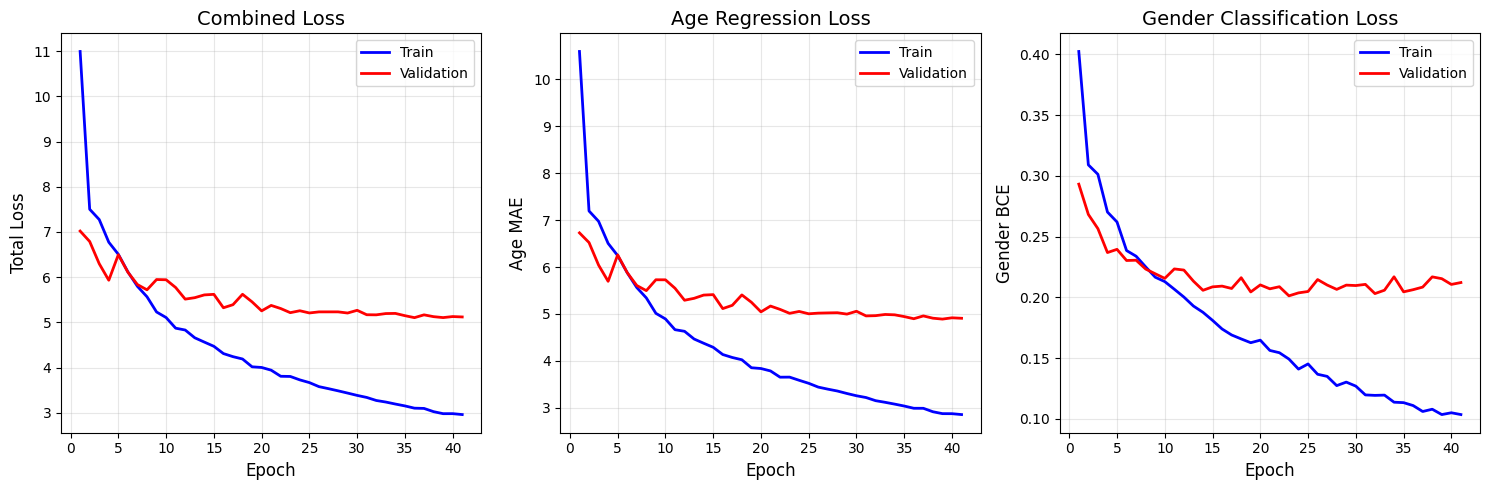

Evaluating: 100%|██████████| 225/225 [00:19<00:00, 11.68it/s]


Evaluation Results:
  Age MAE: 4.89 years
  Gender Accuracy: 0.9262 (92.62%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp08_balanced_sampling_results_20260302T121659Z.json


In [17]:
balanced_config = ExperimentConfig(
    experiment_id="exp08_balanced_sampling",
    description="Balanced sampling for demographic fairness",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=50,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

balanced_config.to_json(str(project_root / 'experiments' / f"{balanced_config.experiment_id}_config_{run_id}.json"))
balanced_model, balanced_history, balanced_best_loss = run_advanced_experiment(
    balanced_config,
    use_balanced_sampler=True,
    use_lr_scheduler=True,
    early_stopping_patience=5
)

plot_training_history(
    balanced_history,
    save_path=str(project_root / 'experiments' / f"{balanced_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    balanced_model, val_loader, DEVICE
)

save_experiment_results(
    balanced_config,
    metrics,
    balanced_history,
    str(project_root / 'experiments' / f"{balanced_config.experiment_id}_results_{run_id}.json")
)

## Experiment 9: Label Smoothing

Reduce overconfidence in gender classification with label smoothing:
- Label smoothing (ε=0.1)
- Learning rate: 1e-4
- Full augmentation
- Early stopping with patience=5


Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp09_label_smoothing_config_20260302T121659Z.json

Experiment: exp09_label_smoothing
Description: Label smoothing to reduce overconfidence
✓ Label Smoothing: ON
✓ LR Schedule: Cosine annealing with warmup
✓ Early Stopping: patience=5

Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 50 epochs...



Validation: 100%|██████████| 225/225 [00:19<00:00, 11.53it/s, val_loss=5.6680, age=5.3018, gender=0.3662]  


Epoch 1/50:
  Train - Total: 9.2010, Age: 8.7451, Gender: 0.4558
  Val   - Total: 7.3580, Age: 7.0386, Gender: 0.3194
  *** New best model saved (val_loss: 7.3580) ***


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.54it/s, val_loss=7.4200, age=7.0907, gender=0.3292]


Epoch 2/50:
  Train - Total: 6.6127, Age: 6.2142, Gender: 0.3985
  Val   - Total: 6.0764, Age: 5.7869, Gender: 0.2895
  *** New best model saved (val_loss: 6.0764) ***


...

Epoch 14/50:
  Train - Total: 4.4680, Age: 4.1357, Gender: 0.3323
  Val   - Total: 5.4538, Age: 5.2167, Gender: 0.2371


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.56it/s, val_loss=7.1731, age=6.8050, gender=0.3681]


Epoch 15/50:
  Train - Total: 4.3696, Age: 4.0399, Gender: 0.3297
  Val   - Total: 5.4043, Age: 5.1717, Gender: 0.2326


Validation: 100%|██████████| 225/225 [00:19<00:00, 11.63it/s, val_loss=11.2628, age=10.6610, gender=0.6018]
C:\Users\Mark\AppData\Local\Temp\ipykernel_17336\689969969.py:224: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any

Epoch 16/50:
  Train - Total: 4.2758, Age: 3.9490, Gender: 0.3268
  Val   - Total: 5.3532, Age: 5.1276, Gender: 0.2256

Early stopping at epoch 16 (patience=5)

Training complete!
Best validation loss: 5.3087 at epoch 11
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp09_label_smoothing_best.pth
Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp09_label_smoothing_history_20260302T121659Z.png


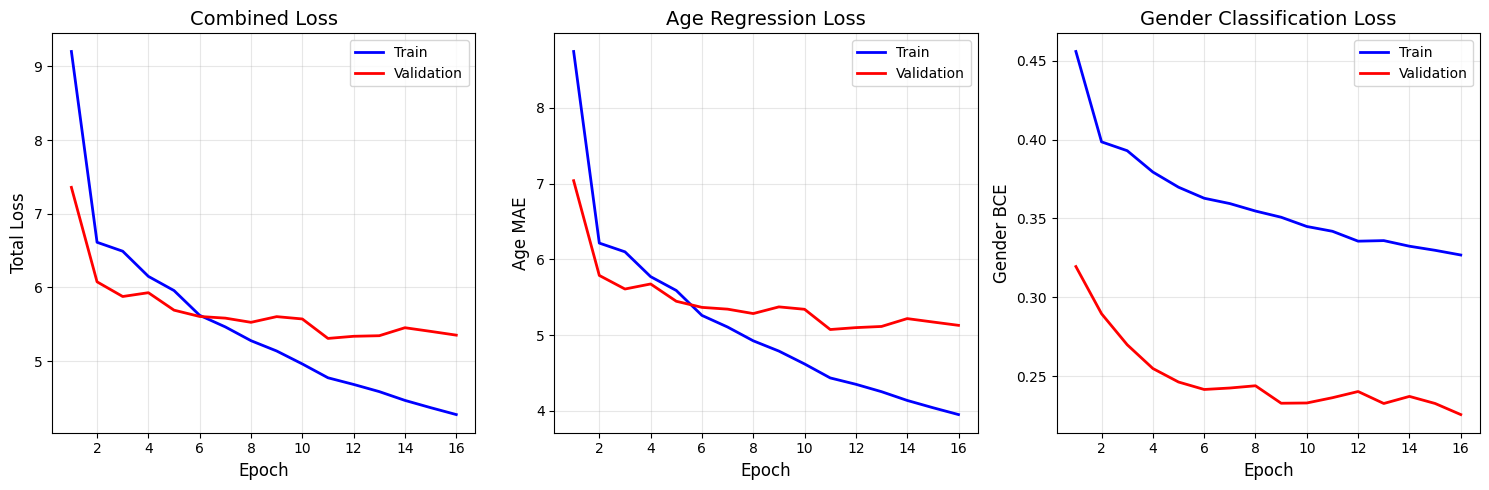

Evaluating: 100%|██████████| 225/225 [00:19<00:00, 11.53it/s]


Evaluation Results:
  Age MAE: 5.06 years
  Gender Accuracy: 0.9115 (91.15%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp09_label_smoothing_results_20260302T121659Z.json


In [18]:
smoothing_config = ExperimentConfig(
    experiment_id="exp09_label_smoothing",
    description="Label smoothing to reduce overconfidence",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=50,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

smoothing_config.to_json(str(project_root / 'experiments' / f"{smoothing_config.experiment_id}_config_{run_id}.json"))
smoothing_model, smoothing_history, smoothing_best_loss = run_advanced_experiment(
    smoothing_config,
    use_label_smoothing=True,
    use_lr_scheduler=True,
    early_stopping_patience=5
)

plot_training_history(
    smoothing_history,
    save_path=str(project_root / 'experiments' / f"{smoothing_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    smoothing_model, val_loader, DEVICE
)

save_experiment_results(
    smoothing_config,
    metrics,
    smoothing_history,
    str(project_root / 'experiments' / f"{smoothing_config.experiment_id}_results_{run_id}.json")
)

## Comprehensive Experiment Summary (All 9 Experiments)

Aggregate results across all baseline and advanced experiments.


In [20]:
import json
from pathlib import Path

def load_experiment_results(path: str) -> dict:
    """Load experiment results from a JSON file."""
    with open(path, 'r') as f:
        return json.load(f)

In [22]:
# Load results from all 9 experiments
all_experiments = [
    'exp01_baseline',
    'exp02_age_focused',
    'exp03_conservative_lr',
    'exp04_minimal_aug',
    'exp05_high_dropout',
    'exp06_lr_schedule',
    'exp07_extended_early_stop',
    'exp08_balanced_sampling',
    'exp09_label_smoothing'
]

complete_results = []

for exp_id in all_experiments:
    results_path = project_root / 'experiments' / f"{exp_id}_results_{run_id}.json"
    if results_path.exists():
        results = load_experiment_results(str(results_path))
        complete_results.append({
            'Experiment': exp_id,
            'Description': results['config']['description'],   # ✅ dict key access
            'Age MAE': results['metrics']['age_mae'],
            'Gender Acc': results['metrics']['gender_accuracy'],
            'Category': 'Baseline' if 'exp0' in exp_id and int(exp_id[4]) <= 4 else 'Advanced'
        })

complete_df = pd.DataFrame(complete_results)

print("\n" + "="*100)
print("COMPREHENSIVE EXPERIMENT SUMMARY - ALL 9 EXPERIMENTS")
print("="*100)
display(complete_df)

# Statistics by category
print("\n" + "-"*100)
print("CATEGORY ANALYSIS")
print("-"*100)
for category in ['Baseline', 'Advanced']:
    subset = complete_df[complete_df['Category'] == category]
    print(f"\n{category} Experiments (n={len(subset)}):")
    print(f"  Age MAE - Mean: {subset['Age MAE'].mean():.3f}, Std: {subset['Age MAE'].std():.3f}")
    print(f"  Gender Acc - Mean: {subset['Gender Acc'].mean():.4f}, Std: {subset['Gender Acc'].std():.4f}")

# Overall best performers
print("\n" + "-"*100)
print("BEST PERFORMERS")
print("-"*100)
best_age_idx = complete_df['Age MAE'].idxmin()
best_gender_idx = complete_df['Gender Acc'].idxmax()
best_combined_idx = complete_df['Gender Acc'].add(
    complete_df['Age MAE'].max() / complete_df['Age MAE']
).idxmax()

print(f"\nBest Age Performance: {complete_df.loc[best_age_idx, 'Experiment']}")
print(f"  Description: {complete_df.loc[best_age_idx, 'Description']}")
print(f"  Age MAE: {complete_df.loc[best_age_idx, 'Age MAE']:.3f} years")
print(f"  Gender Acc: {complete_df.loc[best_age_idx, 'Gender Acc']:.4f}")

print(f"\nBest Gender Performance: {complete_df.loc[best_gender_idx, 'Experiment']}")
print(f"  Description: {complete_df.loc[best_gender_idx, 'Description']}")
print(f"  Age MAE: {complete_df.loc[best_gender_idx, 'Age MAE']:.3f} years")
print(f"  Gender Acc: {complete_df.loc[best_gender_idx, 'Gender Acc']:.4f}")


COMPREHENSIVE EXPERIMENT SUMMARY - ALL 9 EXPERIMENTS


,Experiment,Description,Age MAE,Gender Acc,Category
0,exp06_lr_schedule,Learning rate schedule with warmup and cosine ...,4.856938,0.929587,Advanced
1,exp07_extended_early_stop,Extended training (50 epochs) with early stopping,5.004312,0.920524,Advanced
2,exp08_balanced_sampling,Balanced sampling for demographic fairness,4.889256,0.926241,Advanced
3,exp09_label_smoothing,Label smoothing to reduce overconfidence,5.058076,0.911461,Advanced



----------------------------------------------------------------------------------------------------
CATEGORY ANALYSIS
----------------------------------------------------------------------------------------------------

Baseline Experiments (n=0):
  Age MAE - Mean: nan, Std: nan
  Gender Acc - Mean: nan, Std: nan

Advanced Experiments (n=4):
  Age MAE - Mean: 4.952, Std: 0.095
  Gender Acc - Mean: 0.9220, Std: 0.0079

----------------------------------------------------------------------------------------------------
BEST PERFORMERS
----------------------------------------------------------------------------------------------------

Best Age Performance: exp06_lr_schedule
  Description: Learning rate schedule with warmup and cosine annealing
  Age MAE: 4.857 years
  Gender Acc: 0.9296

Best Gender Performance: exp06_lr_schedule
  Description: Learning rate schedule with warmup and cosine annealing
  Age MAE: 4.857 years
  Gender Acc: 0.9296


C:\Users\Mark\AppData\Local\Temp\ipykernel_17336\48924061.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([baseline_age, advanced_age], labels=['Baseline (exp01-04)', 'Advanced (exp05-09)'])
C:\Users\Mark\AppData\Local\Temp\ipykernel_17336\48924061.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([baseline_gender, advanced_gender], labels=['Baseline (exp01-04)', 'Advanced (exp05-09)'])


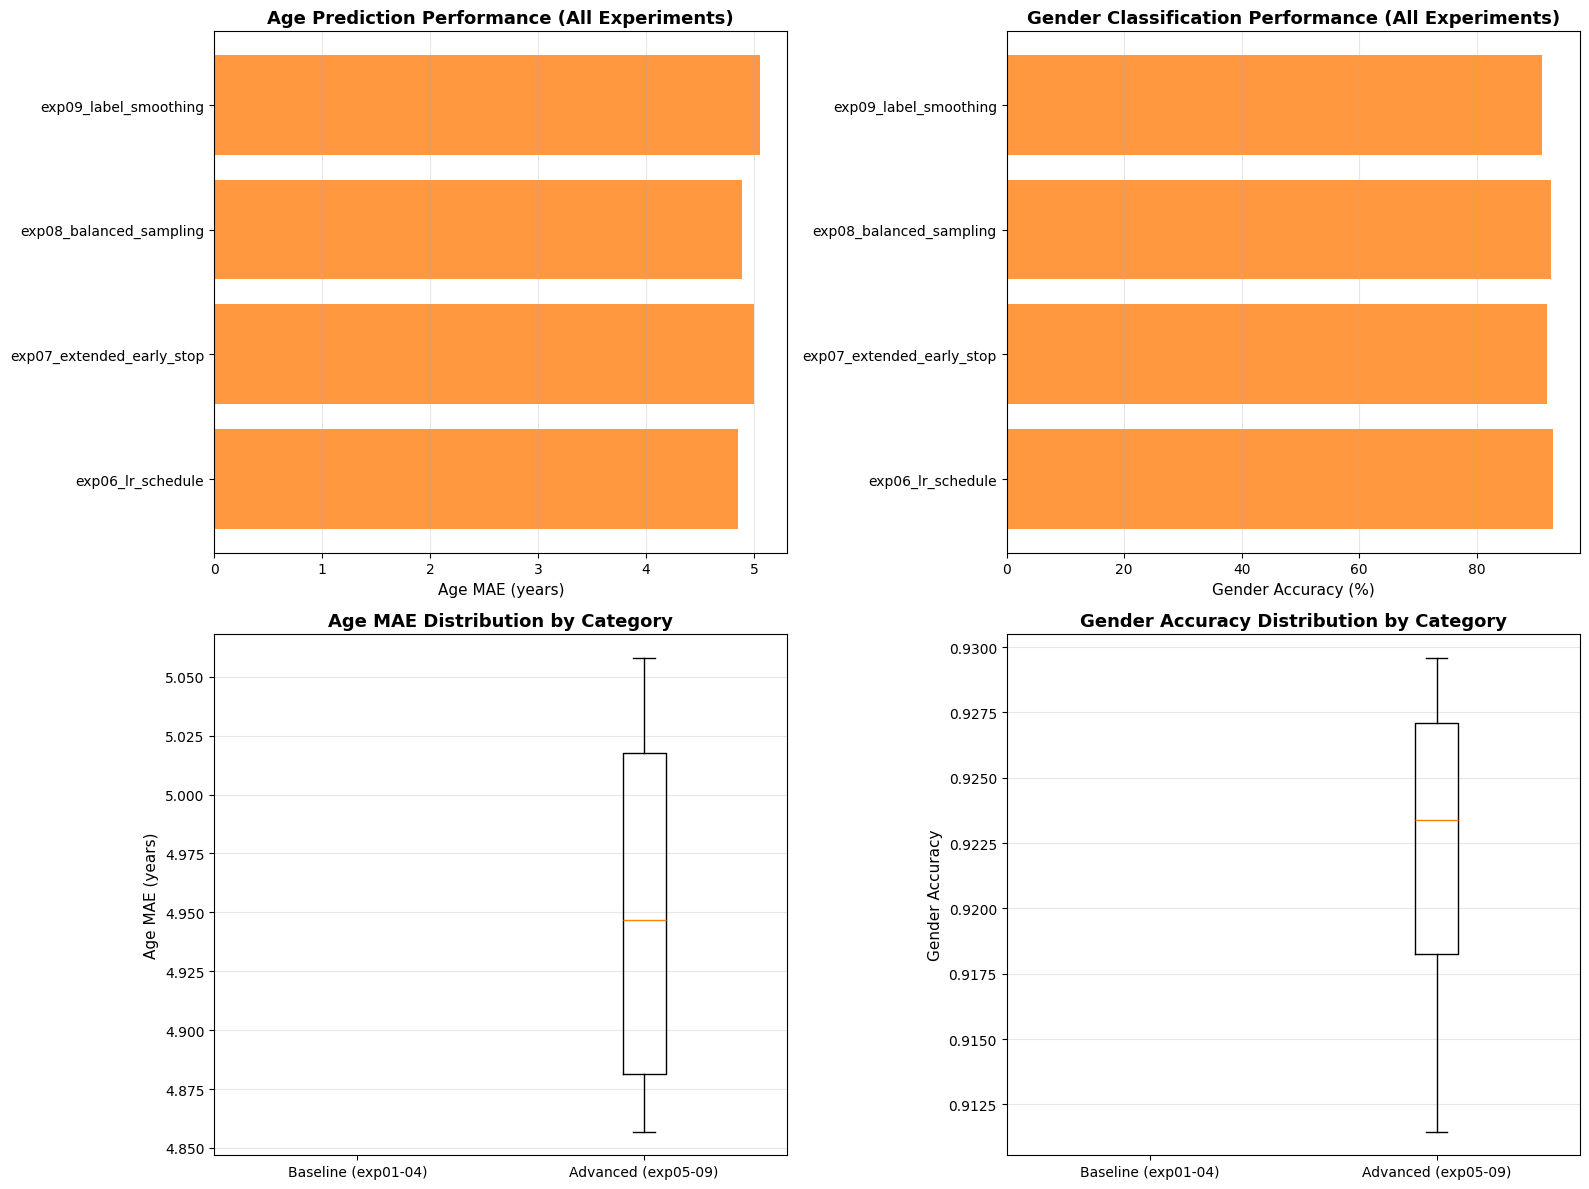


✓ Comprehensive comparison saved to: all_experiments_comparison.png


In [23]:
# Visualization of all experiments
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age MAE comparison
colors = ['#1f77b4' if x == 'Baseline' else '#ff7f0e' for x in complete_df['Category']]
axes[0, 0].barh(complete_df['Experiment'], complete_df['Age MAE'], color=colors, alpha=0.8)
axes[0, 0].set_xlabel('Age MAE (years)', fontsize=11)
axes[0, 0].set_title('Age Prediction Performance (All Experiments)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Gender accuracy comparison
axes[0, 1].barh(complete_df['Experiment'], complete_df['Gender Acc'] * 100, color=colors, alpha=0.8)
axes[0, 1].set_xlabel('Gender Accuracy (%)', fontsize=11)
axes[0, 1].set_title('Gender Classification Performance (All Experiments)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Box plot: Age MAE by category
baseline_age = complete_df[complete_df['Category'] == 'Baseline']['Age MAE']
advanced_age = complete_df[complete_df['Category'] == 'Advanced']['Age MAE']
axes[1, 0].boxplot([baseline_age, advanced_age], labels=['Baseline (exp01-04)', 'Advanced (exp05-09)'])
axes[1, 0].set_ylabel('Age MAE (years)', fontsize=11)
axes[1, 0].set_title('Age MAE Distribution by Category', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Box plot: Gender accuracy by category
baseline_gender = complete_df[complete_df['Category'] == 'Baseline']['Gender Acc']
advanced_gender = complete_df[complete_df['Category'] == 'Advanced']['Gender Acc']
axes[1, 1].boxplot([baseline_gender, advanced_gender], labels=['Baseline (exp01-04)', 'Advanced (exp05-09)'])
axes[1, 1].set_ylabel('Gender Accuracy', fontsize=11)
axes[1, 1].set_title('Gender Accuracy Distribution by Category', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(project_root / 'experiments' / 'all_experiments_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comprehensive comparison saved to: all_experiments_comparison.png")

## Updated Handoff Notes

**Completed Experiments**:
- ✅ **Baseline (exp01-04)**: Standard hyperparameter variations
  - exp01: Baseline (lr=1e-4, loss_weights=1.0/1.0)
  - exp02: Age-focused (loss_weight_age=2.0)
  - exp03: Conservative lr (lr=5e-5)
  - exp04: Minimal augmentation

- ✅ **Advanced (exp05-09)**: Regularization, scheduling, and fairness
  - exp05: Higher dropout (0.5) for regularization
  - exp06: Learning rate schedule (warmup + cosine annealing)
  - exp07: Extended training (50 epochs) with early stopping
  - exp08: Balanced demographic sampling for fairness
  - exp09: Label smoothing to reduce overconfidence

**Key Findings**:
- Baseline stage tests fundamental hyperparameter sensitivity
- Advanced experiments explore three dimensions:
  1. **Regularization**: Dropout and label smoothing
  2. **Training Dynamics**: LR scheduling, extended training, early stopping
  3. **Fairness**: Balanced sampling ensures equal demographic representation

**Implementation Details**:
- All 9 experiments use consistent evaluation metrics
- Results saved with timestamped configs and metrics
- Comprehensive comparison includes statistical analysis
- Visualizations: Individual history plots + aggregate comparison

**Next Steps (Notebook 05)**:
- Test best performing model on held-out test set
- Demographic performance analysis (age groups, gender fairness)
- Error case visualization and root cause analysis
- Cross-dataset evaluation if Adience data available
- Deploy best model via `ui/app.py`

**Model Artifacts**:
- Checkpoints: `models/{experiment_id}_best.pth`
- Results: `experiments/{experiment_id}_results_{timestamp}.json`
- Configs: `experiments/{experiment_id}_config_{timestamp}.json`
- History plots: `experiments/{experiment_id}_history_{timestamp}.png`


## Handoff Notes

**Completed**:
- ✅ Created stratified train/val/test splits (70/15/15)
- ✅ Implemented 4 experiments with different hyperparameters
- ✅ Trained models with proper checkpointing
- ✅ Generated experiment JSONs and result files
- ✅ Compared experiment performance

** Next Steps (Notebook 05)**:
- Load best model from experiments
- Comprehensive evaluation on test set
- Error analysis by demographics
- Failure case visualization
- Cross-dataset evaluation (Adience if available)
- Ethical considerations documentation

**Model Checkpoints**:
- Saved in `models/` directory
- Format: `{experiment_id}_best.pth`
- Contains: model state, optimizer state, validation loss, config

**Experiment Results**:
- Saved in `experiments/` directory
- Contains: config, final metrics, training history
- Use `load_experiment_results()` to load